# Two steps burn-in process

In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import emcee
import corner
from time import time
from lib import *

%matplotlib widget
plt.close("all")

In [2]:
# load the data and filter it by only picking stars near the equatorial plane (|b| < 5 deg)
gaia = Table.read("d3.gz")
mask = abs(gaia['b']) < 5
gaia_filtered = gaia[mask]

# note: we should also filter by parallax error if we dind't do it in the query!!!!

# extract the relevant columns
l = gaia_filtered["l"]
b = gaia_filtered["b"]
parallax = gaia_filtered["parallax"]
parallax_error = gaia_filtered["parallax_error"]
radial_velocity = gaia_filtered["radial_velocity"]
radial_velocity_error = gaia_filtered["radial_velocity_error"]

In [3]:
# unit conversion:
#   [velocity] = km/s
#   [distance] = kpc
#   [longitude/latitude] = radians

d_from_sun = 1 / parallax # distance from sun in kpc
l_rad = np.radians(l) # longitude in radians
b_rad = np.radians(b) # latitude in radians

print(f"Number of stars: {len(d_from_sun)}")

Number of stars: 75659


In [4]:
# vectorized version of log_probability for emcee with vectorize=True, which allows us to evaluate the log-probability for multiple sets of parameters at once (one for each walker)

def log_likelihood_vect(theta, V_rad, l, d, v_rad_error, parallax_error, V_rot_fixed):
    # theta is formatted as ((V_rot1, U01, V01), (V_rot2, U02, V02), ...)
    V_rot = theta[:, 0][:, np.newaxis]   # (nwalkers, 1)
    U0    = theta[:, 1][:, np.newaxis]
    V0    = theta[:, 2][:, np.newaxis]

    R = distance_from_gc(l, 0, d, R0)

    # V_rad as function of V_rot (and l)
    model =  velocity_model(l, 0, d, R0, V_rot, U0, V0, 0)

    sigma2 = v_rad_error**2 + (model_derivative(l, 0, R0, V_rot_fixed, d, R, parallax) * parallax_error)**2

    # return value should be an array of log-likelihoods, one for each set of parameters in theta
    return -np.sum(0.5 * np.log(2.0 * np.pi * sigma2) + 0.5 * (V_rad - model)**2 / sigma2, axis=1)

def log_prior_vect(theta):
    V_rot = theta[:, 0]
    U0 = theta[:, 1]
    V0 = theta[:, 2]

    # set the prior to be uniform, but set some bounds on the parameters

    mask = (0.0 < V_rot) & (V_rot < 400.0) & (-50.0 < U0) & (U0 < 50.0) & (-50.0 < V0) & (V0 < 50.0)

    log_pri = np.full(theta.shape[0], -np.inf)
    log_pri[mask] = 0.0

    return log_pri

def log_probability_vect(theta, V_rad, l, d, v_rad_error, parallax_error, V_rot_fixed):
    log_pri = log_prior_vect(theta)
    log_prob = np.full(theta.shape[0], -np.inf)

    valid = np.isfinite(log_pri)

    if np.any(valid):
        log_prob[valid] = log_likelihood_vect(
            theta[valid], V_rad, l, d, v_rad_error, parallax_error, V_rot_fixed
        ) + log_pri[valid]
        
    return log_prob

L'algoritmo è eseguito in due passaggi. Il primo passaggio consiste in una run breve (circa $2*\tau$ step) in cui i walker sono inizializzati con valori casuali (incluso v_rot_fixed, usato nella propagazione dell'errore), con lo scopo di identificare la regione ad alta probabilità. Il secondo passaggio è l'analisi vera e propria con i walker inizializzati con valori che meglio riflettono la forma della distribuzione.

In [ ]:
# we do two separate runs of MCMC:
    # a shorter one, with random initial positions and a rough order of magnitude estimate of V_rot
    # a longer one, with initial positions centered around the best-fit parameters from the first run, and a much better estimate of V_rot

# --- FIRST RUN ---
nwal = 32
n_iters_first = 100
V_rot_fixed_first = 100.0 # initial guess for V_rot, which is needed to propagate the parallax error in the likelihood
p0 = np.array([220.0, 10.0, 10.0]) # initial guess for (V_rot, U0, V0)
pos = p0 + np.array([10.0, 5.0, 5.0]) * np.random.randn(nwal, 3) # initial positions of the walkers, randomly distributed around the initial guess

sampler_first = emcee.EnsembleSampler(nwal, 3, log_probability_vect, args=(radial_velocity, l_rad, d_from_sun, radial_velocity_error, parallax_error, V_rot_fixed_first), vectorize=True)
sampler_first.run_mcmc(pos, n_iters_first, progress=True)

# we now can extract the samples, cut off the burn-in, and compute an estimate of V_rot and fit a gaussian to the posterior to get a better start distibution for the second run
samples_first = sampler_first.get_chain(flat=True)
burnin_first = round(n_iters_first * 0.8)
prev_samples = samples_first[burnin_first:]

# compute the median and 1-sigma uncertainties for each parameter from the samples
V_rot_mcmc_prev, U0_mcmc_prev, V0_mcmc_prev = np.percentile(samples_first, [16, 50, 84], axis=0).T

# extract the uncertainties as the 16th and 84th percentiles (2/3s confidence interval)
V_rot_uncertainty = np.abs(V_rot_mcmc_prev[0] - V_rot_mcmc_prev[2])
U0_uncertainty = np.abs(U0_mcmc_prev[0] - U0_mcmc_prev[2])
V0_uncertainty = np.abs(V0_mcmc_prev[0] - V0_mcmc_prev[2])

V_rot_prev_samples = prev_samples[:, 0]
U0_prev_samples = prev_samples[:, 1]
V0_prev_samples = prev_samples[:, 2]

V_rot_avg = np.mean(V_rot_prev_samples)
U0_avg = np.mean(U0_prev_samples)
V0_avg = np.mean(V0_prev_samples)

print(f"First run results:")
print(f"V_rot: {V_rot_avg:.2f} ± {V_rot_uncertainty:.2f} km/s")
print(f"U0: {U0_avg:.2f} ± {U0_uncertainty:.2f} km/s")
print(f"V0: {V0_avg:.2f} ± {V0_uncertainty:.2f} km/s")

# --- SECOND RUN ---
n_iters_second = 5000
V_rot_fixed_second = V_rot_avg # we can now use the estimate of V_rot from the first run to propagate the parallax error in the likelihood more accurately
p0_second = np.array([V_rot_avg, U0_avg, V0_avg]) # initial guess for (V_rot, U0, V0) based on the results of the first run
sigmas = np.array([V_rot_uncertainty, U0_uncertainty, V0_uncertainty]) # uncertainties from the first run to set the scale of the initial positions for the second run
pos_second = np.random.normal(p0_second, sigmas, size=(nwal, 3)) # initial positions of the walkers, randomly distributed around the initial guess from the first run

sampler_second = emcee.EnsembleSampler(nwal, 3, log_probability_vect, args=(radial_velocity, l_rad, d_from_sun, radial_velocity_error, parallax_error, V_rot_fixed_second), vectorize=True)
sampler_second.run_mcmc(pos_second, n_iters_second, progress=True)


100%|██████████| 1000/1000 [00:49<00:00, 20.10it/s]


First run results:
V_rot: 220.55 ± 0.12 km/s
U0: -10.60 ± 0.01 km/s
V0: -21.42 ± 0.01 km/s


100%|██████████| 5000/5000 [04:07<00:00, 20.23it/s]


State([[221.84000213 -10.30284253 -21.40291589]
 [221.73545263 -10.31663411 -21.39822488]
 [221.859056   -10.31119774 -21.39528071]
 [221.79055999 -10.30603267 -21.40305966]
 [221.83545712 -10.31296451 -21.39836664]
 [221.80515435 -10.31702262 -21.40277911]
 [221.74508579 -10.30415119 -21.39864954]
 [221.72036348 -10.31893086 -21.39937881]
 [221.82767764 -10.30618227 -21.40022635]
 [221.76184818 -10.29958443 -21.39361242]
 [221.6617535  -10.31261774 -21.40796558]
 [221.76315064 -10.3118119  -21.40044464]
 [221.90188656 -10.3109095  -21.40699225]
 [221.84368525 -10.31187131 -21.40675096]
 [221.8175775  -10.31270671 -21.39529313]
 [221.89609053 -10.30666162 -21.39852938]
 [221.93034314 -10.30945011 -21.40371235]
 [221.89558252 -10.31205259 -21.40194368]
 [221.91315784 -10.31037688 -21.40068474]
 [221.90543548 -10.30876092 -21.40208521]
 [221.83882118 -10.31165948 -21.40301475]
 [221.86617842 -10.31054307 -21.40338337]
 [221.7501244  -10.31077899 -21.4009777 ]
 [221.80053161 -10.30574829 

In [6]:
# exract the samples from the second run, cut off the burn-in, and compute the final estimates of the parameters
tau = sampler_second.get_autocorr_time()
burn_in = int(2 * np.max(tau))
thin = int(0.5 * np.min(tau))

samples_second = sampler_second.get_chain(discard=burn_in, thin=thin, flat=True)

# compute the median and 1-sigma uncertainties for each parameter from the samples
V_rot_mcmc, U0_mcmc, V0_mcmc = np.percentile(samples_second, [16, 50, 84], axis=0).T

V_rot_samples = samples_second[:, 0]
U0_samples = samples_second[:, 1]
V0_samples = samples_second[:, 2]

# extract the best-fit parameters (the median of the posterior distribution) as medians
V_rot_best = V_rot_mcmc[1]
U0_best = U0_mcmc[1]
V0_best = V0_mcmc[1]

# extract the uncertainties as the 16th and 84th percentiles (2/3s confidence interval)
V_rot_uncertainty = np.abs(V_rot_mcmc[0] - V_rot_mcmc[2])
U0_uncertainty = np.abs(U0_mcmc[0] - U0_mcmc[2])
V0_uncertainty = np.abs(V0_mcmc[0] - V0_mcmc[2])

# print the best values
print(f"Best-fit V_rot: {V_rot_best:.2f} km/s ± {V_rot_uncertainty:.2f} km/s")
print(f"Best-fit U0: {U0_best:.2f} ± {U0_uncertainty:.2f}")
print(f"Best-fit V0: {V0_best:.2f} ± {V0_uncertainty:.2f}")

Best-fit V_rot: 221.84 km/s ± 0.15 km/s
Best-fit U0: -10.31 ± 0.01
Best-fit V0: -21.40 ± 0.01


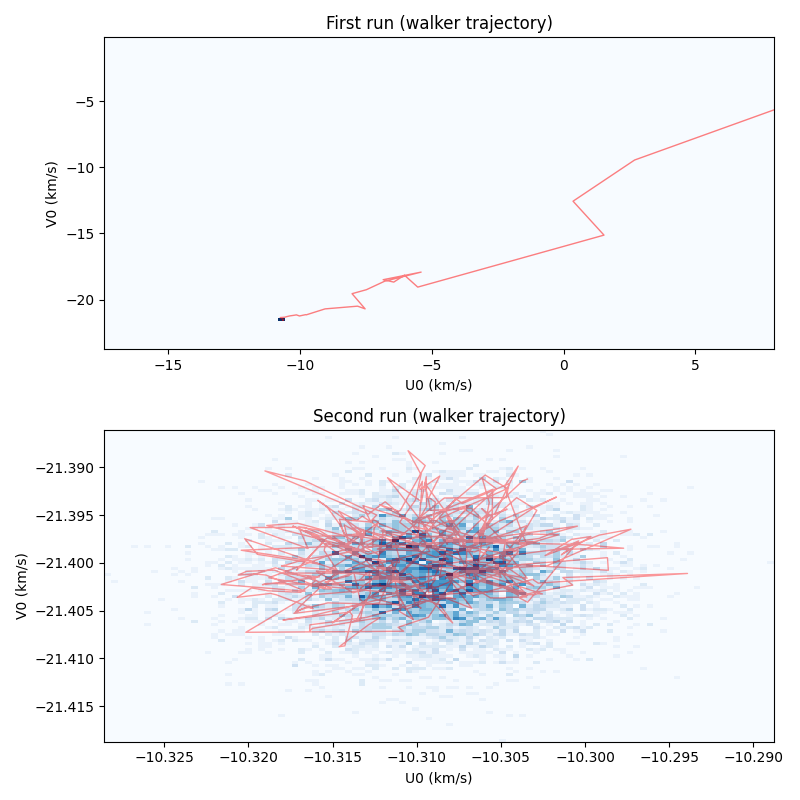

In [28]:
# plot an heightmap of the posterior dist of U0 and V0, for both the first and second run
# add a trajectory for a single walker on both plots, to show how the walkers move in the parameter space during the burn-in phase
# in-between the two runs, show how the initial positions of the walkers for the second run are distributed around the best-fit parameters from the first run

walker_path_first = sampler_first.get_chain()[:, 0, 1:3] # trajectory of the first walker in the first run
walker_path_second = sampler_second.get_chain()[:, 0, 1:3][200:1000] # trajectory of the first walker in the second run

initial_pos_second = pos_second[:, 1:3] # initial positions of the walkers in the second run

bins = 100

plt.figure(figsize=(8, 8))

plt.subplot(2, 1, 1)
plt.title("First run (walker trajectory)")
plt.hist2d(U0_prev_samples, V0_prev_samples, bins=bins, cmap="Blues")
plt.xlabel("U0 (km/s)")
plt.ylabel("V0 (km/s)")
plt.plot(walker_path_first[:, 0], walker_path_first[:, 1], 'r-', linewidth=1, alpha=0.5)

plt.subplot(2, 1, 2)
plt.title("Second run (walker trajectory)")
plt.hist2d(U0_samples, V0_samples, bins=bins, cmap="Blues")
plt.xlabel("U0 (km/s)")
plt.ylabel("V0 (km/s)")
plt.plot(walker_path_second[:, 0], walker_path_second[:, 1], 'r-', linewidth=1, alpha=0.4)

plt.tight_layout()
plt.show()